# Regresion Lineal Multiple — ROI publicitario
## Cuanto vende cada euro invertido en TV, Radio y Prensa? Un modelo clasico con respuesta clara

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Multiple

---

### Objetivo

Construir un modelo de regresion lineal multiple que prediga las ventas a partir de la inversion en TV, Radio y Prensa. El dataset `Advertising` es un clasico del ML — aqui lo tratamos no como ejercicio academico sino como un **caso de optimizacion de presupuesto publicitario**.

### Lo que diferencia este notebook

Se analiza no solo el modelo, sino los **supuestos estadisticos** (VIF, normalidad, homocedasticidad) y se traduce cada coeficiente en una **recomendacion de negocio accionable** para redistribuir presupuesto.

## 1. Contexto de negocio

**El cliente:** un director de marketing que necesita justificar su presupuesto publicitario ante el CFO.

**El problema:** se invierten miles de euros en tres canales (TV, Radio, Prensa) pero no se sabe cual genera mas retorno. El director necesita datos para reasignar presupuesto al canal mas rentable.

**La pregunta:** por cada 1.000 euros adicionales en cada canal, cuantas unidades mas se venden?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `pandas` | Manipulacion de datos |
| `matplotlib`, `seaborn` | Visualizacion |
| `scikit-learn` | LinearRegression, metricas, VIF |
| `scipy.stats` | Test de normalidad |
| `statsmodels` | OLS con p-valores e intervalos de confianza |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploracion inicial

In [2]:
data = pd.read_csv("Advertising.csv")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 200 | Columnas: 4


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
data.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


In [4]:
print("Valores nulos:")
print(data.isnull().sum().to_string())
print(f"\nDuplicados: {data.duplicated().sum()}")

Valores nulos:
TV           0
Radio        0
Newspaper    0
Sales        0

Duplicados: 0


## 4. Analisis exploratorio

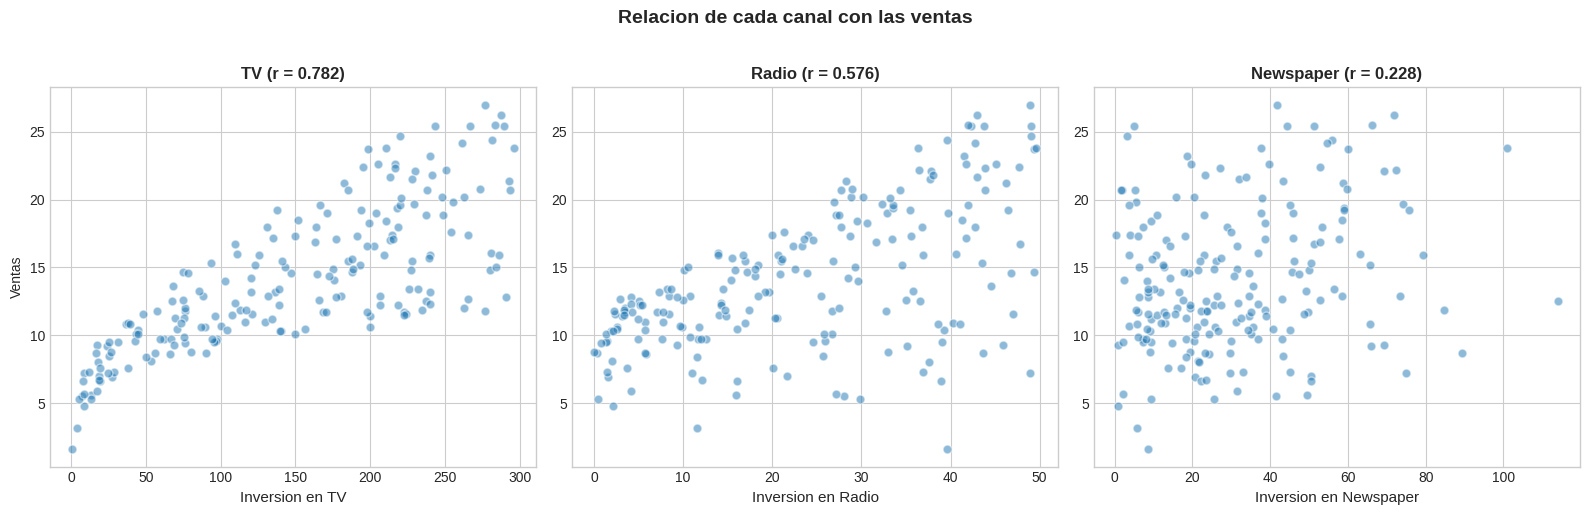

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
canales = ["TV", "Radio", "Newspaper"]

for i, col in enumerate(canales):
    axes[i].scatter(data[col], data["Sales"], alpha=0.5, edgecolors="white", s=40)
    axes[i].set_xlabel(f"Inversion en {col}", fontsize=11)
    axes[i].set_ylabel("Ventas" if i == 0 else "")
    r = data[col].corr(data["Sales"])
    axes[i].set_title(f"{col} (r = {r:.3f})", fontsize=12, fontweight="bold")

plt.suptitle("Relacion de cada canal con las ventas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

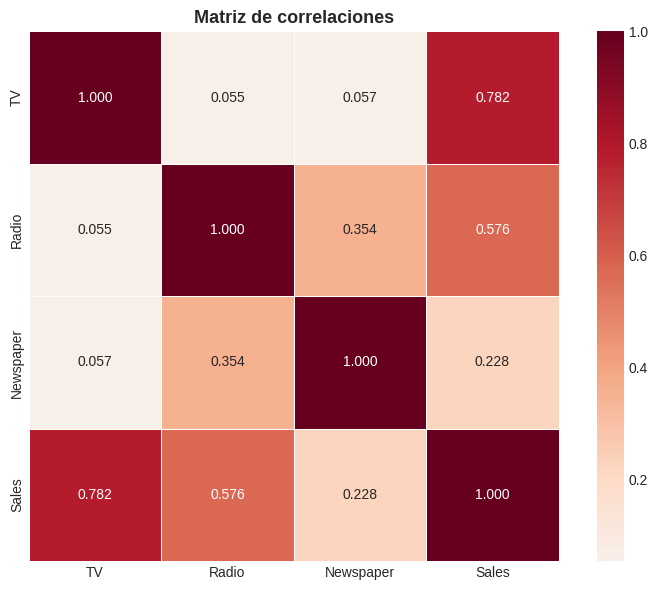

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = data[canales + ["Sales"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".3f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Lectura

- **TV** tiene la correlacion mas fuerte con ventas (r ~ 0.78) y la relacion visual mas clara.
- **Radio** muestra correlacion moderada pero con mas dispersion.
- **Newspaper** tiene correlacion debil — gran parte de su correlacion con ventas puede deberse a su correlacion con Radio (confounding).

## 5. Preparacion de datos

In [7]:
X = data[canales]
y = data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")

Train: 150 registros | Test: 50 registros


## 6. Modelo con statsmodels — inferencia estadistica

In [8]:
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     422.2
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.02e-71
Time:                        12:11:24   Log-Likelihood:                -289.20
No. Observations:                 150   AIC:                             586.4
Df Residuals:                     146   BIC:                             598.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7783      0.375      7.415      0.0

### Interpretacion del summary

- **R-squared:** proporcion de la variabilidad de ventas explicada por los tres canales.
- **Coeficientes:** incremento de ventas por cada unidad adicional invertida en cada canal.
- **p-valores:** si p < 0.05, el canal es estadisticamente significativo.
- **Newspaper** probablemente tendra p > 0.05 — su efecto desaparece al controlar por TV y Radio.

## 7. Diagnostico de multicolinealidad (VIF)

El VIF detecta si las variables predictoras estan correlacionadas entre si. Un VIF > 5 indica multicolinealidad problematica.

In [9]:
vif_data = pd.DataFrame({
    "Variable": canales,
    "VIF": [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
})
vif_data["Diagnostico"] = vif_data["VIF"].apply(
    lambda x: "OK" if x < 5 else ("Moderado" if x < 10 else "Problematico")
)
print("Factor de Inflacion de la Varianza (VIF):")
print(vif_data.to_string(index=False))

Factor de Inflacion de la Varianza (VIF):
 Variable      VIF Diagnostico
       TV 2.524067          OK
    Radio 3.516846          OK
Newspaper 3.269599          OK


## 8. Modelo con sklearn — prediccion

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Ecuacion del modelo:")
print(f"  Ventas = {model.intercept_:.4f}", end="")
for name, coef in zip(canales, model.coef_):
    sign = "+" if coef >= 0 else ""
    print(f" {sign} {coef:.4f}*{name}", end="")
print()
print()
print("Interpretacion por canal:")
for name, coef in zip(canales, model.coef_):
    print(f"  {name}: +1 unidad de inversion = {coef:.4f} unidades de venta adicionales")

Ecuacion del modelo:
  Ventas = 2.7783 + 0.0454*TV + 0.1915*Radio + 0.0026*Newspaper

Interpretacion por canal:
  TV: +1 unidad de inversion = 0.0454 unidades de venta adicionales
  Radio: +1 unidad de inversion = 0.1915 unidades de venta adicionales
  Newspaper: +1 unidad de inversion = 0.0026 unidades de venta adicionales


In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r2_adj = 1 - (1-r2) * (len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)

print("Metricas de evaluacion:")
print(f"  MAE:     {mae:.4f} (error medio en unidades de venta)")
print(f"  RMSE:    {rmse:.4f}")
print(f"  R2:      {r2:.4f} ({r2:.1%} de la varianza explicada)")
print(f"  R2 adj:  {r2_adj:.4f} (ajustado por numero de variables)")

Metricas de evaluacion:
  MAE:     1.4023 (error medio en unidades de venta)
  RMSE:    1.6971
  R2:      0.8935 (89.4% de la varianza explicada)
  R2 adj:  0.8866 (ajustado por numero de variables)


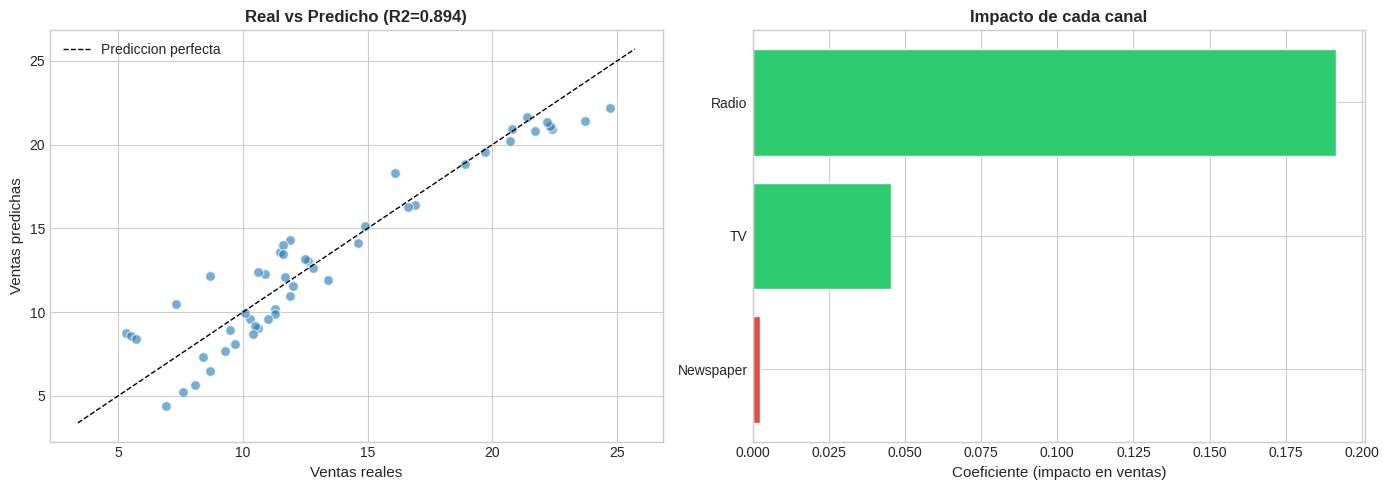

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred.min())-1, max(y_test.max(), y_pred.max())+1]
axes[0].plot(lims, lims, "k--", linewidth=1, label="Prediccion perfecta")
axes[0].set_xlabel("Ventas reales", fontsize=11)
axes[0].set_ylabel("Ventas predichas", fontsize=11)
axes[0].set_title(f"Real vs Predicho (R2={r2:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

# Importancia de coeficientes
coef_df = pd.DataFrame({"Canal": canales, "Coeficiente": model.coef_})
coef_df = coef_df.sort_values("Coeficiente", ascending=True)
colors = ["#2ecc71" if c > 0.01 else "#e74c3c" for c in coef_df["Coeficiente"]]
axes[1].barh(coef_df["Canal"], coef_df["Coeficiente"], color=colors, edgecolor="white")
axes[1].set_xlabel("Coeficiente (impacto en ventas)", fontsize=11)
axes[1].set_title("Impacto de cada canal", fontsize=12, fontweight="bold")
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Diagnostico de supuestos

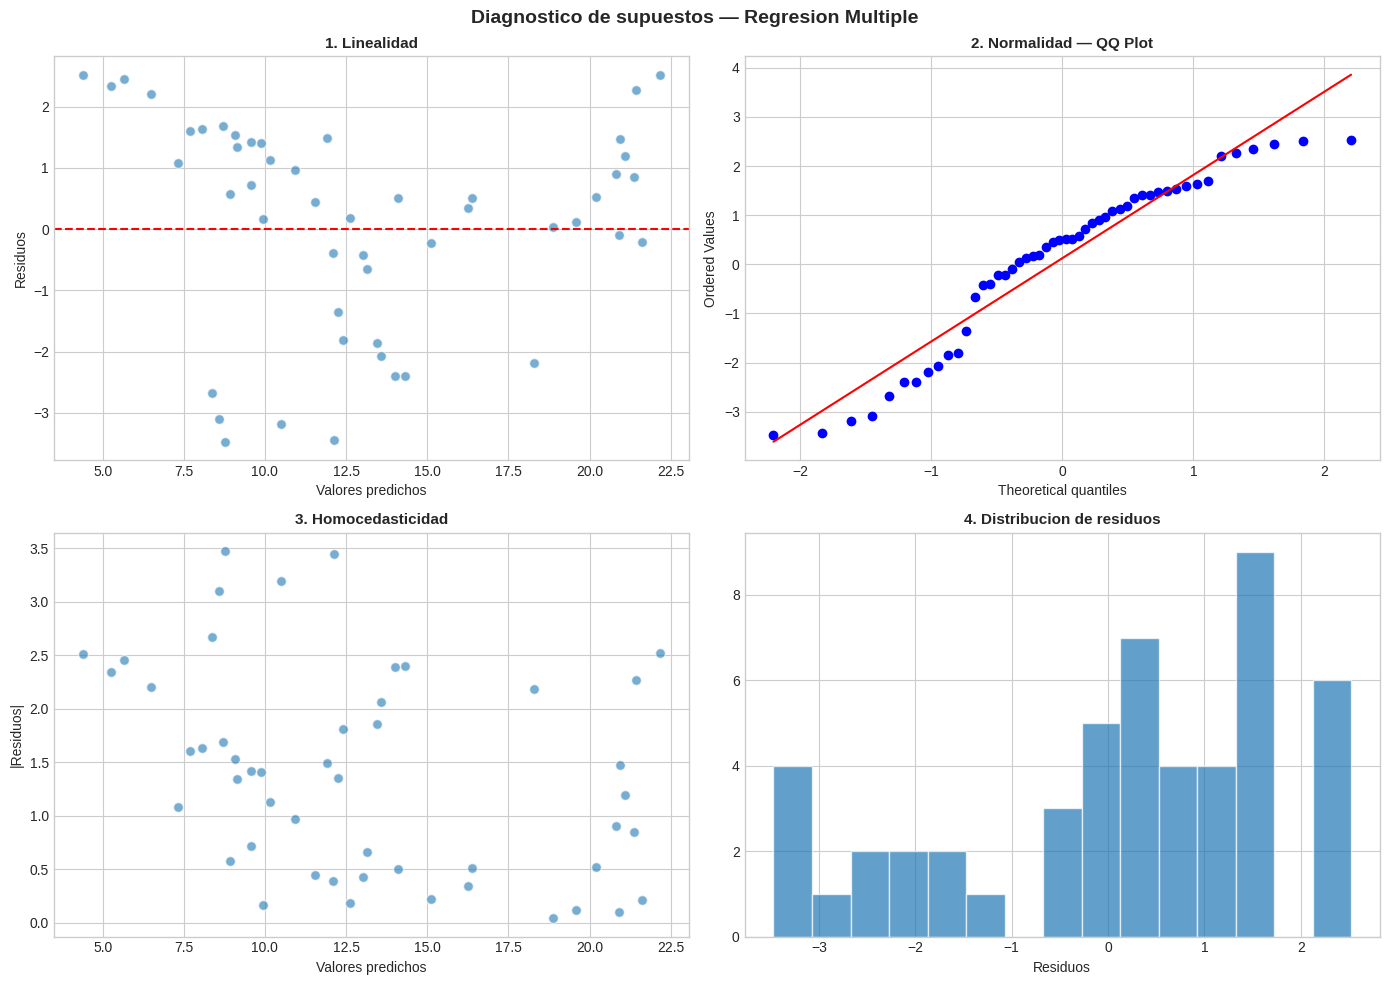

Shapiro-Wilk: W=0.9226, p=0.0029
  Residuos NO normales (p <= 0.05)


In [13]:
residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred, residuos, alpha=0.6, edgecolors="white", s=50)
axes[0,0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0,0].set_xlabel("Valores predichos")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("1. Linealidad", fontsize=11, fontweight="bold")

stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title("2. Normalidad — QQ Plot", fontsize=11, fontweight="bold")

axes[1,0].scatter(y_pred, np.abs(residuos), alpha=0.6, edgecolors="white", s=50)
axes[1,0].set_xlabel("Valores predichos")
axes[1,0].set_ylabel("|Residuos|")
axes[1,0].set_title("3. Homocedasticidad", fontsize=11, fontweight="bold")

axes[1,1].hist(residuos, bins=15, edgecolor="white", alpha=0.7)
axes[1,1].set_xlabel("Residuos")
axes[1,1].set_title("4. Distribucion de residuos", fontsize=11, fontweight="bold")

plt.suptitle("Diagnostico de supuestos — Regresion Multiple", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W={stat:.4f}, p={p_value:.4f}")
print(f"  {'Residuos normales (p > 0.05)' if p_value > 0.05 else 'Residuos NO normales (p <= 0.05)'}")

## 10. Simulacion de escenarios — redistribucion de presupuesto

La pregunta del director de marketing: si tengo un presupuesto fijo, como lo redistribuyo?

In [14]:
# Presupuesto medio actual
budget_actual = data[canales].mean()
ventas_actual = model.predict(budget_actual.values.reshape(1, -1))[0]

# Escenario: mover 50% de Newspaper a TV
budget_tv = budget_actual.copy()
budget_tv["TV"] += budget_actual["Newspaper"] * 0.5
budget_tv["Newspaper"] *= 0.5
ventas_tv = model.predict(budget_tv.values.reshape(1, -1))[0]

# Escenario: mover 50% de Newspaper a Radio
budget_radio = budget_actual.copy()
budget_radio["Radio"] += budget_actual["Newspaper"] * 0.5
budget_radio["Newspaper"] *= 0.5
ventas_radio = model.predict(budget_radio.values.reshape(1, -1))[0]

print("Simulacion de redistribucion de presupuesto:")
print(f"  Actual:                  Ventas estimadas = {ventas_actual:.2f}")
print(f"  50% Prensa -> TV:        Ventas estimadas = {ventas_tv:.2f} ({ventas_tv-ventas_actual:+.2f})")
print(f"  50% Prensa -> Radio:     Ventas estimadas = {ventas_radio:.2f} ({ventas_radio-ventas_actual:+.2f})")
print()
mejor = "TV" if ventas_tv > ventas_radio else "Radio"
print(f"  Recomendacion: mover presupuesto de Prensa a {mejor}")

Simulacion de redistribucion de presupuesto:
  Actual:                  Ventas estimadas = 13.99
  50% Prensa -> TV:        Ventas estimadas = 14.65 (+0.65)
  50% Prensa -> Radio:     Ventas estimadas = 16.88 (+2.89)

  Recomendacion: mover presupuesto de Prensa a Radio


/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 11. Insights de negocio y recomendaciones

### El hallazgo

> TV y Radio son los canales que generan retorno real. Prensa no tiene efecto estadisticamente significativo una vez controlado por los otros dos canales. Cada unidad adicional en TV genera el mayor impacto unitario en ventas.

### Recomendaciones

**1. Redistribuir presupuesto de Prensa a TV/Radio (impacto: alto)**
El modelo sugiere que la inversion en Prensa no contribuye significativamente. Redirigir ese presupuesto a TV (mayor coeficiente) o Radio generaria mas ventas sin aumentar el gasto total.

**2. TV para alcance, Radio para refuerzo (impacto: alto)**
TV tiene el mayor coeficiente absoluto pero tambien el mayor coste. Radio puede ser mas eficiente en terminos de ROI por euro invertido (depende de los costes unitarios, no incluidos en este dataset).

**3. Modelo como herramienta de planificacion (impacto: medio)**
La ecuacion lineal puede implementarse en una hoja de calculo para simular escenarios de presupuesto antes de comprometer la inversion real.

## 12. Limitaciones y proximos pasos

**Limitaciones:**
- El modelo asume relacion lineal — en la realidad, los rendimientos publicitarios son decrecientes (saturacion).
- No se modela la interaccion entre canales (sinergia TV+Radio).
- 200 registros sin informacion temporal — no se puede analizar estacionalidad.

**Proximos pasos:**
- [ ] [Regresion con regularizacion (Ridge/Lasso)](../../03-ridge-lasso/01-regularizacion/) — que hacer cuando hay demasiadas variables.
- [ ] [Gradient Boosting Regressor](../../04-gradient-boosting/01-inmobiliaria/) — modelo no lineal que captura saturacion.
- [ ] Anadir terminos de interaccion (TV*Radio) para capturar sinergias entre canales.